# Deep Q-Learning with Policy and Target network for Frozen-walk game

This notebook aims at training, validating and testing a reinforncement learning agent using Deep Q-Learning with Policy and Target network for Frozen-walk game. The notebook includes: 
1. Initiate a Frozen lake environment and an agent.  
2. Train the agent using <b>Deep Q-Learning with Policy and Target network</b>.  
3. Print out the optimal policy, i.e., what is the best action at a stage.  

Frozen lake involves crossing a frozen lake from start to goal without falling into any holes by walking over the frozen lake. The player may not always move in the intended direction due to the slippery nature of the frozen lake.

![Frozen walk](https://gymnasium.farama.org/_images/frozen_lake.gif)

More details can be found at https://gymnasium.farama.org/environments/toy_text/frozen_lake/.

### Install libraries and initiate a frozen lake map

In [ ]:
# Install gymnasium game environment
!pip install gymnasium
!pip install gymnasium[toy-text]

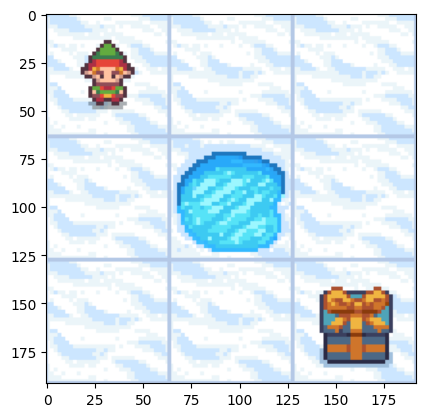

In [ ]:
### Please do not change this code

# Load libraries
import gymnasium as gym
import matplotlib.pyplot as plt

# Define environment map
custom_map = [
    'SFF',
    'FHF',
    'FFG'
]

# Initialize the environment\
env = gym.make('FrozenLake-v1', desc=custom_map, is_slippery=False, render_mode='rgb_array')
state_size = env.observation_space.n    # Number of states
action_size = env.action_space.n    # Number of actions of this game: four, 0: left, 1:down, 2: right, 3: up.
env.reset()    # Reset environment, i.e., set agent position to state 0
plt.imshow(env.render())    # Visualize environment map

In [ ]:
# Load libraries
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib
from keras.optimizers import Adam
from keras.layers import Dense
from keras.models import Sequential
from collections import deque
import imageio
import pandas as pd

In [ ]:
# Define the Agent class with target network
class Agent:
    def __init__(self, state_size, action_size):
        self.memory = deque(maxlen=2048)
        self.batch_size = 256
        self.learning_rate = 0.001
        self.epsilon = 1.0  # Start with full exploration
        self.min_eps = 0.01
        self.eps_decay = 0.003
        self.gamma = 0.9  # Discount factor
        self.state_size = state_size
        self.action_size = action_size
        self.episode = 0
        self.max_steps = 50
        self.train_episodes = 501

        # Create policy network and target network
        self.model = self.build_model()
        self.target_model = self.build_model()
        self.update_target_model()  # Initialize target model

    def build_model(self):
        model = Sequential()
        model.add(Dense(10, input_dim=self.state_size, activation='relu'))
        model.add(Dense(self.action_size, activation='linear'))
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        """Copy weights from the policy model to the target model"""
        self.target_model.set_weights(self.model.get_weights())

    def add_memory(self, state, action, reward, new_state, terminated):
        self.memory.append((state, action, reward, new_state, terminated))

    def action(self, state):
        if np.random.rand() > self.epsilon:
            return np.argmax(self.model.predict(state, verbose=0))
        return env.action_space.sample()

    def replay(self):
        if len(self.memory) < self.batch_size:
            return  # Skip training if not enough samples in memory

        minibatch = random.sample(self.memory, self.batch_size)
        minibatch_state = np.concatenate(np.array(minibatch, dtype=object)[:, 0], axis=0)
        minibatch_action = np.array(minibatch, dtype=object)[:, 1]
        minibatch_reward = np.array(minibatch, dtype=object)[:, 2]
        minibatch_new_state = np.concatenate(np.array(minibatch, dtype=object)[:, 3], axis=0)
        minibatch_terminated = np.array(minibatch, dtype=object)[:, 4]

        # Get Q-values from policy and target network
        q_state = self.model.predict(minibatch_state, verbose=0)
        q_new_state = self.target_model.predict(minibatch_new_state, verbose=0)

        # Compute target Q-values
        q_action_optimal = np.add(minibatch_reward, self.gamma * np.amax(q_new_state, axis=1) * (1 - minibatch_terminated))
        for i in range(self.batch_size):
            q_state[i][minibatch_action[i]] = q_action_optimal[i]

        self.model.fit(minibatch_state, q_state, epochs=1, verbose=0)

    def save_model(self, name):
        self.model.save_weights(name)

    def load_model(self, name):
        self.model.load_weights(name)

In [ ]:
# Initialize agent
agent = Agent(state_size, action_size)
reward_episodes = []
step_episodes = []
epsilon_episodes = []

for episode in range(agent.train_episodes):
    agent.episode = episode
    state = env.reset()
    state_arr = np.zeros(agent.state_size)
    state_arr[state[0]] = 1
    state_arr = np.reshape(state_arr, [1, agent.state_size])
    reward = 0
    terminated = False
    img_lst = [env.render()]

    for step in range(agent.max_steps):
        action = agent.action(state_arr)
        new_state, reward, terminated, _, _ = env.step(action)
        new_state_arr = np.zeros(agent.state_size)
        new_state_arr[new_state] = 1
        new_state_arr = np.reshape(new_state_arr, [1, agent.state_size])

        agent.add_memory(state_arr, action, reward, new_state_arr, terminated)
        state_arr = new_state_arr

        if agent.episode % 50 == 0:
            img = env.render()
            img_lst.append(img)

        if terminated:
            break

    print(f"Episode: {agent.episode}, Steps: {step}, Epsilon: {round(agent.epsilon, 2)}, Reward: {reward}")
    reward_episodes.append(reward)
    step_episodes.append(step)
    epsilon_episodes.append(agent.epsilon)

    # Update epsilon for exploration-exploitation balance
    agent.epsilon = max(agent.min_eps, np.exp(-agent.eps_decay * agent.episode))

    # Train model if memory is sufficient
    agent.replay()

    # Update target network every 10 episodes
    if episode % 10 == 0:
        agent.update_target_model()

    # Save training animation every 50 episodes
    if len(img_lst) > 1:
        animation_file = f"training_episode_{agent.episode}_steps_{step}.gif"
        imageio.mimsave(animation_file, img_lst, format='GIF', duration=0.5)

print("Average success rate of training episodes:", round(np.mean(reward_episodes), 2))
agent.save_model(f'model_{agent.episode}.weights.h5')

Episode: 0, Steps: 6, Epsilon: 1.0, Reward: 0.0
Episode: 1, Steps: 5, Epsilon: 1.0, Reward: 0.0
Episode: 2, Steps: 8, Epsilon: 1.0, Reward: 0.0
Episode: 3, Steps: 1, Epsilon: 0.99, Reward: 0.0
Episode: 4, Steps: 3, Epsilon: 0.99, Reward: 0.0
Episode: 5, Steps: 4, Epsilon: 0.99, Reward: 0.0
Episode: 6, Steps: 4, Epsilon: 0.99, Reward: 0.0
Episode: 7, Steps: 2, Epsilon: 0.98, Reward: 0.0
Episode: 8, Steps: 14, Epsilon: 0.98, Reward: 0.0
Episode: 9, Steps: 12, Epsilon: 0.98, Reward: 0.0
Episode: 10, Steps: 8, Epsilon: 0.97, Reward: 1.0
Episode: 11, Steps: 6, Epsilon: 0.97, Reward: 0.0
Episode: 12, Steps: 19, Epsilon: 0.97, Reward: 0.0
Episode: 13, Steps: 8, Epsilon: 0.96, Reward: 0.0
Episode: 14, Steps: 6, Epsilon: 0.96, Reward: 0.0
Episode: 15, Steps: 13, Epsilon: 0.96, Reward: 1.0
Episode: 16, Steps: 4, Epsilon: 0.96, Reward: 0.0
Episode: 17, Steps: 3, Epsilon: 0.95, Reward: 0.0
Episode: 18, Steps: 5, Epsilon: 0.95, Reward: 0.0
Episode: 19, Steps: 16, Epsilon: 0.95, Reward: 0.0
Episode:

### Plot cumulative average success rate over training episodes

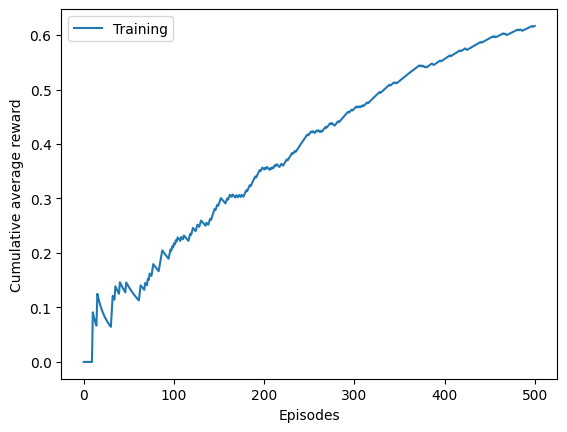

In [ ]:
df_reward_episodes = pd.DataFrame(reward_episodes)
cumulative_average_rewards = df_reward_episodes.expanding().mean()
plt.plot(cumulative_average_rewards)
plt.ylabel('Cumulative average reward')
plt.xlabel('Episodes')
plt.legend(['Training'], loc='upper left')
matplotlib.rcParams.update({'font.size': 10})
plt.show()

### Plot cumulative average steps of over training episodes

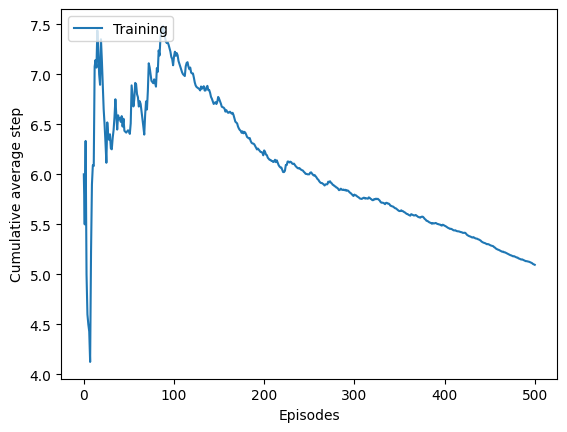

In [ ]:
df_step_episodes = pd.DataFrame(step_episodes)
cumulative_average_steps = df_step_episodes.expanding().mean()
plt.plot(cumulative_average_steps)
plt.ylabel('Cumulative average step')
plt.xlabel('Episodes')
plt.legend(['Training'], loc='upper left')
matplotlib.rcParams.update({'font.size': 10})
plt.show()

### Plot epsilon values over training episodes

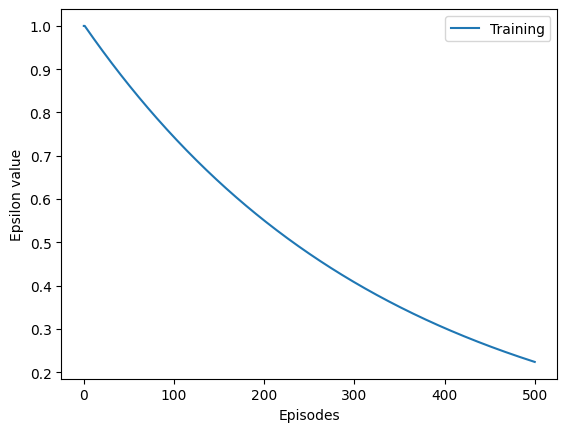

In [ ]:
# Plot epsilon values over episodes
plt.plot(epsilon_episodes)
plt.ylabel('Epsilon value')
plt.xlabel('Episodes')
plt.legend(['Training'], loc='upper right')
matplotlib.rcParams.update({'font.size': 10})
plt.show()

### Print optimal policy

In [ ]:
# Print the optimal policy, i.e., at each state what is the best action to take.
for state_index in range(agent.state_size):
    state_arr=np.zeros(agent.state_size)
    state_arr[state_index] = 1
    state_arr= np.reshape(state_arr, [1, agent.state_size])
    q_values = agent.model.predict(state_arr, verbose=0)
    best_action = np.argmax(q_values)
    print("State " + str(state_index) + ", Best action: " + str(best_action))

State 0, Best action: 2
State 1, Best action: 2
State 2, Best action: 1
State 3, Best action: 1
State 4, Best action: 2
State 5, Best action: 1
State 6, Best action: 2
State 7, Best action: 2
State 8, Best action: 2


In [ ]:
# Test an episode
state = env.reset()
state_arr = np.zeros(agent.state_size)
state_arr[state[0]] = 1
state_arr = np.reshape(state_arr, [1, agent.state_size])
terminated = False
img_lst = [env.render()]
for step in range(agent.max_steps):
    q_values = agent.model.predict(state_arr, verbose=0)
    best_action = np.argmax(q_values)
    new_state, reward, terminated, info, _ = env.step(best_action)
    new_state_arr = np.zeros(agent.state_size)
    new_state_arr[new_state] = 1
    new_state_arr = np.reshape(new_state_arr, [1, agent.state_size])
    print("Current state: " + str(np.argmax(state_arr)) + ", Action: " + str(best_action) + ", New state: " + str(np.argmax(new_state_arr)))
    state_arr = new_state_arr

    img = env.render()
    img_lst.append(img)

    if terminated:
        break

print("Reward: " + str(reward))
imageio.mimsave('test.gif', img_lst, format='GIF', duration=0.5)

Current state: 0, Action: 2, New state: 1
Current state: 1, Action: 2, New state: 2
Current state: 2, Action: 1, New state: 5
Current state: 5, Action: 1, New state: 8
Reward: 1.0


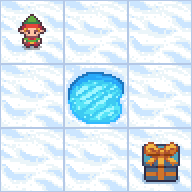

In [ ]:
# Display test result animation
from IPython.display import Image
Image('test.gif')

The training performance with only one policy network shows instability in the early episodes, with sharp fluctuations in the cumulative average reward. In contrast, using both a policy and target network results in a smoother learning curve and more stable convergence, as the target network helps reduce variance in Q-value updates. This demonstrates that incorporating a target network improves training stability and leads to a more reliable policy in the Frozen Lake environment.